In [1]:
import pandas as pd
import numpy as np

In [5]:
studentInfo = pd.read_csv("/content/studentInfo.csv")
studentVle = pd.read_csv("/content/studentVle.csv")
vle = pd.read_csv("/content/vle.csv")
assessments = pd.read_csv("/content/assessments.csv")
studentAssessment = pd.read_csv("/content/studentAssessment.csv")

In [6]:
print(studentInfo.shape)
print(studentVle.shape)
print(studentAssessment.shape)

(32593, 12)
(5935019, 6)
(173912, 5)


In [7]:
module = 'AAA'
presentation = '2013J'

studentInfo = studentInfo[
    (studentInfo['code_module'] == module) &
    (studentInfo['code_presentation'] == presentation)
]

In [8]:
valid_students = studentInfo['id_student'].unique()

studentVle = studentVle[studentVle['id_student'].isin(valid_students)]
studentAssessment = studentAssessment[
    studentAssessment['id_student'].isin(valid_students)
]

In [10]:
studentInfo['dropout'] = np.where(
    studentInfo['final_result'] == 'Withdrawn', 1, 0
)
print(studentInfo['dropout'].value_counts())

dropout
0    323
1     60
Name: count, dtype: int64


In [11]:
engagement_total = (
    studentVle.groupby('id_student')['sum_click']
    .sum()
    .reset_index()
)

engagement_total.rename(
    columns={'sum_click': 'total_clicks'},
    inplace=True
)

In [13]:
studentVle['week'] = studentVle['date'] // 7
weekly_clicks = (
    studentVle.groupby(['id_student', 'week'])['sum_click']
    .sum()
    .reset_index()
)

In [14]:
eng_stats = weekly_clicks.groupby('id_student').agg(
    avg_weekly_clicks=('sum_click', 'mean'),
    std_weekly_clicks=('sum_click', 'std'),
    active_weeks=('week', 'nunique')
).reset_index()

In [15]:
eng_stats['std_weekly_clicks'] = eng_stats['std_weekly_clicks'].fillna(0)

In [16]:
assessment_merged = studentAssessment.merge(
    assessments,
    on='id_assessment',
    how='left'
)

In [17]:
performance = assessment_merged.groupby('id_student').agg(
    avg_score=('score', 'mean'),
    total_assessments=('id_assessment', 'count')
).reset_index()

In [18]:
assessment_merged['delay'] = (
    assessment_merged['date_submitted'] -
    assessment_merged['date']
)

In [19]:
delay_stats = assessment_merged.groupby('id_student').agg(
    avg_delay=('delay', 'mean'),
    late_submissions=('delay', lambda x: (x > 0).sum())
).reset_index()

In [20]:
df = studentInfo[['id_student', 'dropout']].copy()
df = df.merge(engagement_total, on='id_student', how='left')
df = df.merge(eng_stats, on='id_student', how='left')
df = df.merge(performance, on='id_student', how='left')
df = df.merge(delay_stats, on='id_student', how='left')
df.fillna(0, inplace=True)

In [21]:
eng_threshold = df['total_clicks'].quantile(0.30)
df['burnout_proxy'] = np.where(
    (df['total_clicks'] < eng_threshold) &
    (df['avg_score'] < 40) &
    (df['dropout'] == 0),
    1,
    0
)
print(df['burnout_proxy'].value_counts())

burnout_proxy
0    376
1      7
Name: count, dtype: int64


In [22]:
def risk_label(row):
    if row['dropout'] == 1:
        return 'High'
    elif row['burnout_proxy'] == 1:
        return 'Medium'
    else:
        return 'Low'

df['risk_level'] = df.apply(risk_label, axis=1)

In [23]:
print(df.head())
print(df.shape)

   id_student  dropout  total_clicks  avg_weekly_clicks  std_weekly_clicks  \
0       11391        0         934.0          34.592593          40.992738   
1       28400        0        1435.0          42.205882          38.534345   
2       30268        1         281.0          70.250000          40.136226   
3       31604        0        2158.0          56.789474          39.918266   
4       32885        0        1034.0          33.354839          41.159485   

   active_weeks  avg_score  total_assessments  avg_delay  late_submissions  \
0          27.0       82.0                5.0       -1.8               0.0   
1          34.0       66.4                5.0        0.0               2.0   
2           4.0        0.0                0.0        0.0               0.0   
3          38.0       76.0                5.0       -2.0               0.0   
4          31.0       54.4                5.0       11.4               5.0   

   burnout_proxy risk_level  
0              0        Low  
1 

2

In [25]:
studentVle['week'] = studentVle['date'] // 7
weekly_clicks = (
    studentVle.groupby(['id_student', 'week'])['sum_click']
    .sum()
    .reset_index()
)

In [26]:
from sklearn.linear_model import LinearRegression
import numpy as np

def compute_slope(group):
    if len(group) < 2:
        return 0

    X = group['week'].values.reshape(-1,1)
    y = group['sum_click'].values

    model = LinearRegression()
    model.fit(X,y)
    return model.coef_[0]

engagement_trend = (
    weekly_clicks.groupby('id_student')
    .apply(compute_slope)
    .reset_index(name='engagement_slope')
)

/tmp/ipython-input-1111/299006076.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_slope)


In [27]:
df = df.merge(engagement_trend, on='id_student', how='left')
df['engagement_slope'].fillna(0, inplace=True)

/tmp/ipython-input-1111/1649693188.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['engagement_slope'].fillna(0, inplace=True)


In [28]:
def inactivity_streak(group):
    dates = sorted(group['date'].unique())
    if len(dates) < 2:
        return 0

    gaps = np.diff(dates)
    return gaps.max()

inactivity = (
    studentVle.groupby('id_student')
    .apply(inactivity_streak)
    .reset_index(name='max_inactivity_gap')
)

df = df.merge(inactivity, on='id_student', how='left')
df['max_inactivity_gap'].fillna(0, inplace=True)

/tmp/ipython-input-1111/2756150413.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(inactivity_streak)
/tmp/ipython-input-1111/2756150413.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['max_inactivity_gap'].fillna(0, 

In [29]:
max_date = studentVle['date'].max()

recent = studentVle[studentVle['date'] >= max_date - 30]
earlier = studentVle[studentVle['date'] < max_date - 30]

recent_clicks = recent.groupby('id_student')['sum_click'].sum()
earlier_clicks = earlier.groupby('id_student')['sum_click'].sum()

drop_ratio = (
    (earlier_clicks - recent_clicks) /
    (earlier_clicks + 1)
).reset_index(name='last30_activity_drop')

df = df.merge(drop_ratio, on='id_student', how='left')
df['last30_activity_drop'].fillna(0, inplace=True)

/tmp/ipython-input-1111/1952936654.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['last30_activity_drop'].fillna(0, inplace=True)


In [30]:
assessment_merged = studentAssessment.merge(
    assessments,
    on='id_assessment',
    how='left'
)

In [32]:
from sklearn.linear_model import LinearRegression
import numpy as np

def score_slope(group):
    # Remove NaN scores
    group = group.dropna(subset=['score'])

    # Need at least 2 data points
    if len(group) < 2:
        return 0

    X = group['date'].values.reshape(-1,1)
    y = group['score'].values

    model = LinearRegression()
    model.fit(X,y)

    return model.coef_[0]

performance_trend = (
    assessment_merged.groupby('id_student')
    .apply(score_slope)
    .reset_index(name='score_slope')
)

df = df.merge(performance_trend, on='id_student', how='left')
df['score_slope'].fillna(0, inplace=True)

/tmp/ipython-input-1111/1707009212.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(score_slope)
/tmp/ipython-input-1111/1707009212.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['score_slope'].fillna(0, inplace=True)

In [33]:
missed = assessment_merged.groupby('id_student').agg(
    missed_submissions=('date_submitted', lambda x: x.isna().sum())
).reset_index()

df = df.merge(missed, on='id_student', how='left')
df['missed_submissions'].fillna(0, inplace=True)

/tmp/ipython-input-1111/2707625487.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['missed_submissions'].fillna(0, inplace=True)


In [34]:
print(df[['score_slope', 'missed_submissions']].head())

   score_slope  missed_submissions
0     0.013705                 0.0
1    -0.046925                 0.0
2     0.000000                 0.0
3     0.046870                 0.0
4     0.045993                 0.0


In [35]:
import numpy as np

def login_gap_std(group):
    # Unique sorted login days
    dates = np.sort(group['date'].unique())

    # If less than 2 login days, no gap variability
    if len(dates) < 2:
        return 0

    gaps = np.diff(dates)

    return np.std(gaps)

gap_std = (
    studentVle.groupby('id_student')
    .apply(login_gap_std)
    .reset_index(name='login_gap_std')
)

df = df.merge(gap_std, on='id_student', how='left')
df['login_gap_std'].fillna(0, inplace=True)

/tmp/ipython-input-1111/3182726449.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(login_gap_std)
/tmp/ipython-input-1111/3182726449.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['login_gap_std'].fillna(0, inplace=T

In [36]:
print(df['login_gap_std'].describe())

count    383.000000
mean       4.440051
std        4.417642
min        0.000000
25%        1.801240
50%        3.235373
75%        5.405333
max       32.470820
Name: login_gap_std, dtype: float64


In [37]:
df['burst_ratio'] = df['std_weekly_clicks'] / (df['avg_weekly_clicks'] + 1)

In [38]:
print(df[['avg_weekly_clicks','std_weekly_clicks','burst_ratio']].head())

   avg_weekly_clicks  std_weekly_clicks  burst_ratio
0          34.592593          40.992738     1.151721
1          42.205882          38.534345     0.891877
2          70.250000          40.136226     0.563315
3          56.789474          39.918266     0.690753
4          33.354839          41.159485     1.198070


In [39]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

features_to_scale = [
    'engagement_slope',
    'max_inactivity_gap',
    'last30_activity_drop',
    'score_slope',
    'missed_submissions',
    'avg_delay',
    'late_submissions',
    'login_gap_std',
    'burst_ratio'
]

df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

In [40]:
df['engagement_stability_index'] = (
    (1 - df['engagement_slope']) +
    df['max_inactivity_gap'] +
    df['burst_ratio']
) / 3

In [41]:
df['performance_decline_index'] = (
    (1 - df['score_slope']) +
    df['missed_submissions']
) / 2

In [42]:
df['procrastination_score'] = (
    df['avg_delay'] +
    df['late_submissions']
) / 2

In [43]:
df['behavioural_volatility_score'] = (
    df['login_gap_std'] +
    df['burst_ratio']
) / 2

In [44]:
df[['engagement_stability_index',
    'performance_decline_index',
    'procrastination_score',
    'behavioural_volatility_score']].describe()

,engagement_stability_index,performance_decline_index,procrastination_score,behavioural_volatility_score
count,383.000000,383.000000,383.000000,383.000000
mean,0.392759,0.232222,0.366408,0.292621
std,0.080000,0.031879,0.106846,0.117543
min,0.156706,0.000000,0.183316,0.000000
25%,0.340870,0.219664,0.282183,0.213529
50%,0.386820,0.228519,0.355672,0.280781
75%,0.430096,0.240207,0.438300,0.344517
max,0.707557,0.500000,0.821204,0.814773


3

In [45]:
from sklearn.preprocessing import MinMaxScaler

risk_features = [
    'performance_decline_index',
    'procrastination_score',
    'missed_submissions',
    'behavioural_volatility_score'
]

scaler = MinMaxScaler()

df[risk_features] = scaler.fit_transform(df[risk_features])

In [47]:
df['behavioural_risk_score'] = (
    0.30 * df['performance_decline_index'] +
    0.25 * df['procrastination_score'] +
    0.25 * df['missed_submissions'] +
    0.20 * df['behavioural_volatility_score']
)

# Convert to 0–100 scale
df['behavioural_risk_score'] = df['behavioural_risk_score'] * 100

In [48]:
def classify_risk(score):
    if score <= 35:
        return "Low Risk"
    elif score <= 65:
        return "Medium Risk"
    else:
        return "High Risk"

df['risk_category'] = df['behavioural_risk_score'].apply(classify_risk)

In [49]:
df[['behavioural_risk_score', 'risk_category']].head()

,behavioural_risk_score,risk_category
0,25.994844,Low Risk
1,30.445961,Low Risk
2,21.605373,Low Risk
3,21.265653,Low Risk
4,41.677243,Medium Risk


In [50]:
df['risk_category'].value_counts()

,count
risk_category,
Low Risk,333
Medium Risk,50


In [51]:
pd.crosstab(df['risk_category'], df['dropout'], normalize='index')

dropout,0,1
risk_category,,
Low Risk,0.861862,0.138138
Medium Risk,0.720000,0.280000


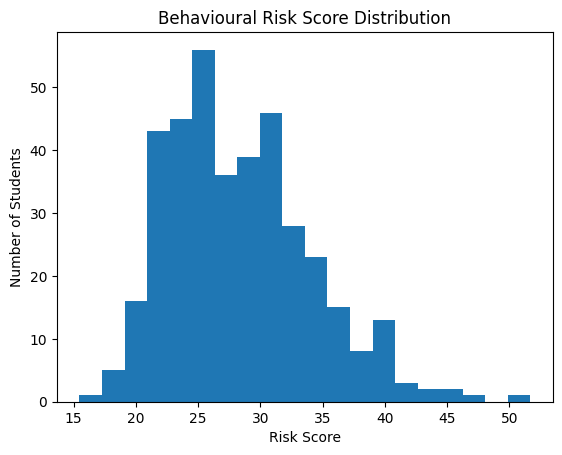

In [52]:
import matplotlib.pyplot as plt

plt.hist(df['behavioural_risk_score'], bins=20)
plt.title("Behavioural Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Number of Students")
plt.show()

In [53]:
df['risk_category'].value_counts()

,count
risk_category,
Low Risk,333
Medium Risk,50


4

In [54]:
df['dropout'].value_counts()

,count
dropout,
0,323
1,60


In [55]:
features = [
    'avg_weekly_clicks',
    'std_weekly_clicks',
    'burst_ratio',
    'login_gap_std',
    'performance_decline_index',
    'procrastination_score',
    'missed_submissions',
    'behavioural_volatility_score'
]

X = df[features]
y = df['dropout']

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [57]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(class_weight='balanced', max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [58]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.5714285714285714
F1 Score: 0.23255813953488372
ROC-AUC: 0.5461538461538461

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.60      0.70        65
           1       0.16      0.42      0.23        12

    accuracy                           0.57        77
   macro avg       0.50      0.51      0.47        77
weighted avg       0.74      0.57      0.63        77



In [59]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [60]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8701298701298701
F1 Score: 0.2857142857142857
ROC-AUC: 0.7814102564102564

Classification Report:

              precision    recall  f1-score   support

           0       0.87      1.00      0.93        65
           1       1.00      0.17      0.29        12

    accuracy                           0.87        77
   macro avg       0.93      0.58      0.61        77
weighted avg       0.89      0.87      0.83        77



In [61]:
!pip install xgboost

In [62]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:43:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [63]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.8701298701298701
F1 Score: 0.5
ROC-AUC: 0.8064102564102564

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.95      0.93        65
           1       0.62      0.42      0.50        12

    accuracy                           0.87        77
   macro avg       0.76      0.69      0.71        77
weighted avg       0.86      0.87      0.86        77



In [64]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

results

,Model,Accuracy,F1 Score,ROC-AUC
0,Logistic Regression,0.571429,0.232558,0.546154
1,Random Forest,0.870130,0.285714,0.781410
2,XGBoost,0.870130,0.500000,0.806410


5

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

rf_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

rf_importance

,feature,importance
5,procrastination_score,0.215680
4,performance_decline_index,0.155036
2,burst_ratio,0.134238
1,std_weekly_clicks,0.133832
0,avg_weekly_clicks,0.129686
7,behavioural_volatility_score,0.121884
3,login_gap_std,0.109645
6,missed_submissions,0.000000


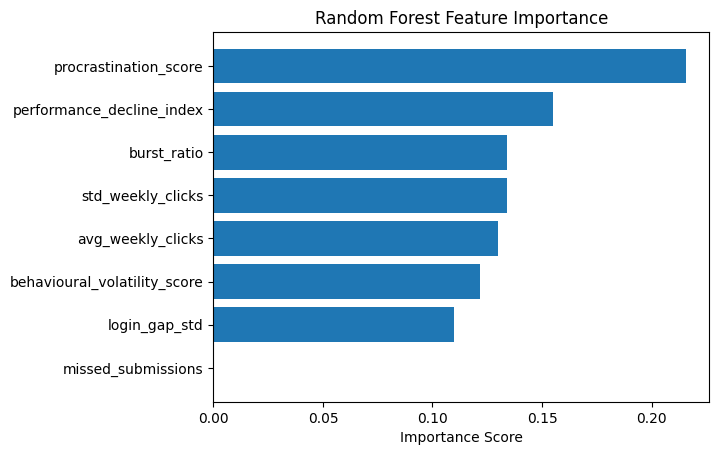

In [66]:
plt.figure()
plt.barh(rf_importance['feature'], rf_importance['importance'])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()

In [67]:
!pip install shap

In [68]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

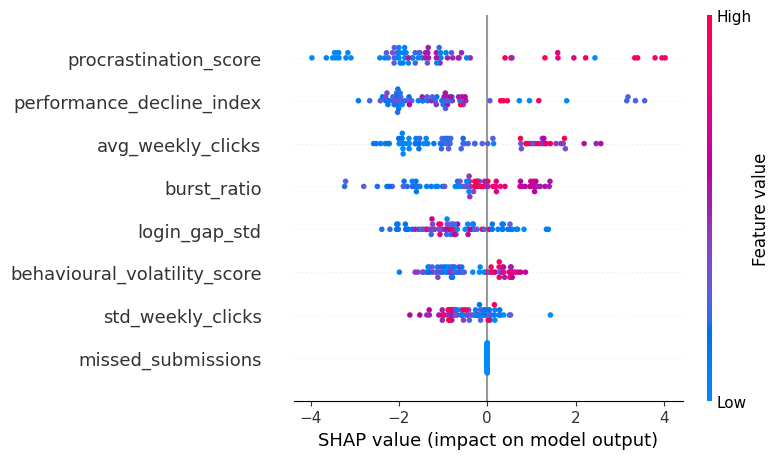

In [69]:
shap.summary_plot(shap_values, X_test)

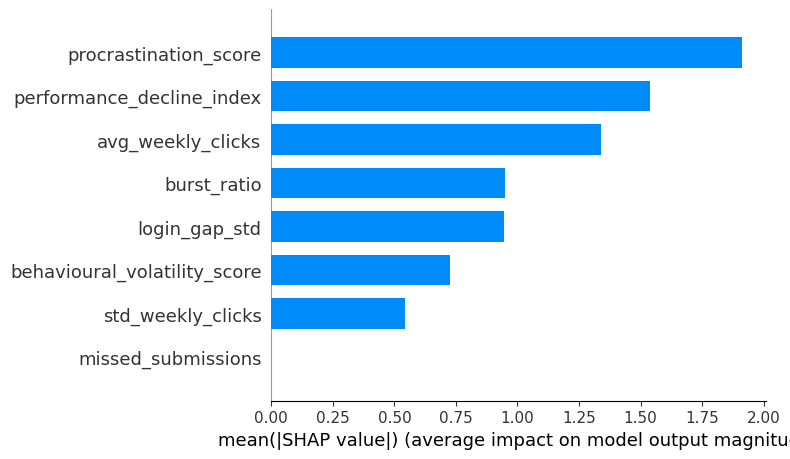

In [70]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

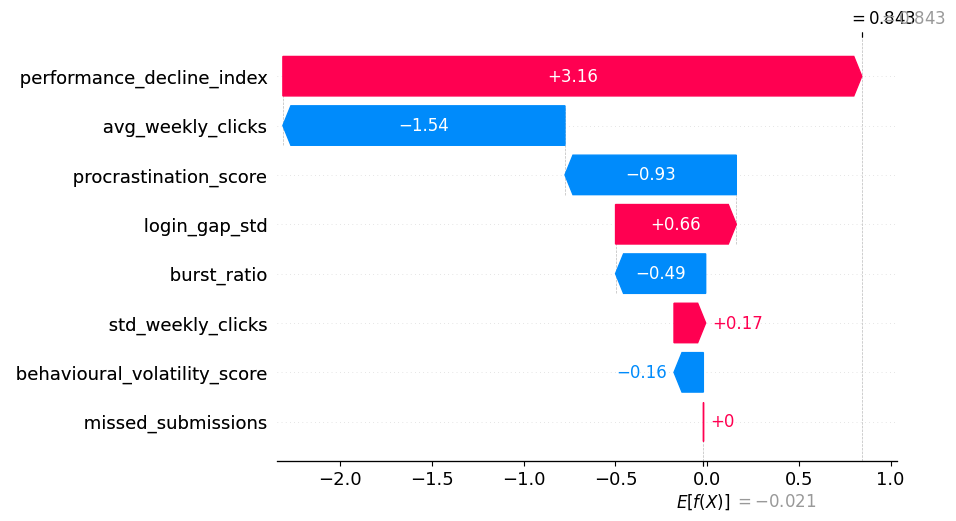

In [73]:
# Pick one dropout prediction
dropout_indices = X_test[y_pred_xgb == 1].index
student_index = dropout_indices[0]

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[list(X_test.index).index(student_index)],
    X_test.loc[student_index]
)

In [74]:
df['trigger_activity_decline'] = df['performance_decline_index'] > 0.40
df['trigger_missed_2plus'] = df['missed_submissions'] >= 2
df['trigger_delay_high'] = df['procrastination_score'] > 0.50
df['trigger_negative_slope'] = df['performance_decline_index'] > 0.30

In [75]:
trigger_cols = [
    'trigger_activity_decline',
    'trigger_missed_2plus',
    'trigger_delay_high',
    'trigger_negative_slope'
]

for col in trigger_cols:
    print("\n", col)
    print(pd.crosstab(df[col], df['dropout'], normalize='index'))


 trigger_activity_decline
dropout                          0         1
trigger_activity_decline                    
False                     0.692308  0.307692
True                      0.848649  0.151351

 trigger_missed_2plus
dropout                      0         1
trigger_missed_2plus                    
False                 0.843342  0.156658

 trigger_delay_high
dropout                    0         1
trigger_delay_high                    
False               0.854985  0.145015
True                0.769231  0.230769

 trigger_negative_slope
dropout                        0         1
trigger_negative_slope                    
False                   1.000000  0.000000
True                    0.842932  0.157068


In [76]:
rf_importance

,feature,importance
5,procrastination_score,0.215680
4,performance_decline_index,0.155036
2,burst_ratio,0.134238
1,std_weekly_clicks,0.133832
0,avg_weekly_clicks,0.129686
7,behavioural_volatility_score,0.121884
3,login_gap_std,0.109645
6,missed_submissions,0.000000


6

In [77]:
df.loc[X_test.index, 'ml_dropout_probability'] = y_prob_xgb

In [78]:
def classify_ml_risk(prob):
    if prob <= 0.35:
        return "Low Risk"
    elif prob <= 0.65:
        return "Medium Risk"
    else:
        return "High Risk"

df['ml_risk_category'] = df['ml_dropout_probability'].apply(
    lambda x: classify_ml_risk(x) if pd.notnull(x) else None
)

In [79]:
def intervention_plan(risk_level):

    if risk_level == "Low Risk":
        return "Send encouragement email + automated study tips"

    elif risk_level == "Medium Risk":
        return "Advisor check-in + study planning resources"

    elif risk_level == "High Risk":
        return "Personal counselling + mentor allocation + academic support"

    else:
        return None

df['intervention_action'] = df['ml_risk_category'].apply(intervention_plan)

In [80]:
def generate_explanation(row):

    reasons = []

    if row['procrastination_score'] > 0.50:
        reasons.append("High submission delay behaviour")

    if row['performance_decline_index'] > 0.40:
        reasons.append("Sustained performance decline")

    if row['burst_ratio'] > 1.2:
        reasons.append("Irregular burst learning pattern")

    if row['login_gap_std'] > 10:
        reasons.append("Inconsistent platform engagement")

    if len(reasons) == 0:
        return "No major behavioural risk detected"

    return "; ".join(reasons)

df['risk_explanation'] = df.apply(generate_explanation, axis=1)

In [81]:
final_alerts = df[
    df['ml_risk_category'].isin(["Medium Risk", "High Risk"])
][[
    'ml_dropout_probability',
    'ml_risk_category',
    'intervention_action',
    'risk_explanation'
]]

final_alerts.head()

,ml_dropout_probability,ml_risk_category,intervention_action,risk_explanation
60,0.394054,Medium Risk,Advisor check-in + study planning resources,High submission delay behaviour; Sustained per...
65,0.469517,Medium Risk,Advisor check-in + study planning resources,High submission delay behaviour; Sustained per...
104,0.378101,Medium Risk,Advisor check-in + study planning resources,High submission delay behaviour; Sustained per...
136,0.699145,High Risk,Personal counselling + mentor allocation + aca...,Sustained performance decline
156,0.528603,Medium Risk,Advisor check-in + study planning resources,Sustained performance decline


7

In [82]:
!pip install plotly

In [83]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

In [84]:
risk_counts = df['ml_risk_category'].value_counts().reset_index()
risk_counts.columns = ['Risk Level', 'Count']

fig = px.bar(
    risk_counts,
    x='Risk Level',
    y='Count',
    color='Risk Level',
    title='Student Risk Distribution'
)

fig.show()

In [85]:
fig = px.bar(
    rf_importance,
    x='importance',
    y='feature',
    orientation='h',
    title='Feature Importance (Random Forest)'
)

fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

In [86]:
student_id = X_test.index[0]

student_data = df.loc[student_id]

student_summary = pd.DataFrame({
    'Metric': [
        'ML Dropout Probability',
        'Performance Decline',
        'Procrastination Score',
        'Burst Ratio',
        'Engagement Volatility'
    ],
    'Value': [
        student_data['ml_dropout_probability'],
        student_data['performance_decline_index'],
        student_data['procrastination_score'],
        student_data['burst_ratio'],
        student_data['behavioural_volatility_score']
    ]
})

fig = px.bar(
    student_summary,
    x='Metric',
    y='Value',
    title=f'Student {student_id} Risk Profile'
)

fig.show()

In [89]:
student_vle = studentVle.copy()

student_vle['week'] = student_vle['date'] // 7

weekly_activity = (
    student_vle.groupby(['id_student', 'week'])['sum_click']
    .sum()
    .reset_index()
)

In [94]:
student_id = 11391

In [95]:
student_activity = weekly_activity[
    weekly_activity['id_student'] == student_id
]

fig = px.line(
    student_activity,
    x='week',
    y='sum_click',
    title=f'Student {student_id} Weekly Activity Trend'
)

fig.show()